# HP k=24 Threshold Optimization

Explore different thresholds for TF-IDF, overlap, Jaccard, and other metrics to find combinations that achieve AUC > 0.58 (better than FoldSeek/TEA) at the superfamily level.

**Goal**: Find the minimum thresholds needed to outperform FoldSeek (AUC=0.574) and TEA (AUC=0.580) using HP k=24.

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from itertools import product
import sys

# Add notebook directory to path for imports
sys.path.insert(0, str(Path.cwd()))
from scope_kmerseek_utils import (
    read_csv_with_size_limit,
    kmerseek_to_rocx,
    plot_sensitivity_from_rocx,
    compute_auc,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

# Target AUC to beat
FOLDSEEK_AUC = 0.574
TEA_AUC = 0.580
TARGET_AUC = TEA_AUC  # Use TEA as the target (slightly higher)

print(f"Target: AUC > {TARGET_AUC} (TEA baseline)")

Target: AUC > 0.58 (TEA baseline)


## 1. Load HP k=24 Data

In [2]:
# Load HP k=24 data
data_dir = Path("/Users/olga/data/scope/results-2025-12-25-average_kmer_rarity")
hp_k24_path = (
    data_dir
    / "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k24.scaled1.kmerseek.results.csv"
)

print("Loading HP k=24...")
hp_k24 = read_csv_with_size_limit(hp_k24_path)
print(f"HP k=24 shape: {hp_k24.shape}")
print(f"Columns: {hp_k24.columns}")

# Add log-transformed features to hp_k24
numeric_cols = [
    "containment",
    "n_intersecting_hashes",
    "jaccard",
    "max_containment",
    "average_abund",
    "median_abund",
    "std_abund",
    "containment_target_in_query",
    "f_weighted_target_in_query",
    "tfidf",
    "average_kmer_frequency",
    "prob_random_cooccurrence",
    "prob_random_cooccurrence_symmetric",
    "expected_intersecting_hashes",
    "observed_over_expected",
    "region_length",
]
log_transforms = [
    pl.when(pl.col(col) >= 0)
    .then((pl.col(col) + 1).log())
    .otherwise(-(-pl.col(col) + 1).log())
    .alias(f"log_{col}")
    for col in numeric_cols
    if col in hp_k24.columns
]
hp_k24 = hp_k24.with_columns(log_transforms)
print(f"Added {len([c for c in hp_k24.columns if c.startswith('log_')])} log features")

hp_k24.head()

Loading HP k=24...
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k24.scaled1.kmerseek.results.csv (0.12 GB) - reading all rows...
HP k=24 shape: (223459, 30)
Columns: ['query_name', 'query_md5', 'target_name', 'target_md5', 'containment', 'n_intersecting_hashes', 'ksize', 'scaled', 'moltype', 'jaccard', 'max_containment', 'average_abund', 'median_abund', 'std_abund', 'containment_target_in_query', 'f_weighted_target_in_query', 'tfidf', 'average_kmer_frequency', 'prob_random_cooccurrence', 'prob_random_cooccurrence_symmetric', 'expected_intersecting_hashes', 'observed_over_expected', 'query_start', 'query_end', 'query_subseq', 'target_start', 'target_end', 'target_subseq', 'moltype_seq', 'region_length']


query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,average_kmer_frequency,prob_random_cooccurrence,prob_random_cooccurrence_symmetric,expected_intersecting_hashes,observed_over_expected,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length
str,str,str,str,f64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,i64,i64,str,str,i64
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""32ed05248bf06ab6""","""d6vbga_ f.38.1.2 (A:) automate…","""ebb66fc6632d8fc0""",1.0,4,24,1,"""hp""",0.010417,1.0,1.375,1.0,0.649519,0.010417,77.2,30.031929,0.00056,9.0636e-14,9.0636e-14,0.002241,1784.705882,0,24,"""ILGAVFYIVFIALFFGIAVGIIFA""",8,32,"""FWMFGLFFFFYFFIMGAYFPFFPI""","""hhhhhhhhhhhhhhhhhhhhhhhh""",24
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""32ed05248bf06ab6""","""d6vbga_ f.38.1.2 (A:) automate…","""ebb66fc6632d8fc0""",1.0,4,24,1,"""hp""",0.010417,1.0,1.375,1.0,0.649519,0.010417,77.2,30.031929,0.00056,9.0636e-14,9.0636e-14,0.002241,1784.705882,0,24,"""ILGAVFYIVFIALFFGIAVGIIFA""",9,33,"""WMFGLFFFFYFFIMGAYFPFFPIW""","""hhhhhhhhhhhhhhhhhhhhhhhh""",24
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""32ed05248bf06ab6""","""d6vbga_ f.38.1.2 (A:) automate…","""ebb66fc6632d8fc0""",1.0,4,24,1,"""hp""",0.010417,1.0,1.375,1.0,0.649519,0.010417,77.2,30.031929,0.00056,9.0636e-14,9.0636e-14,0.002241,1784.705882,0,24,"""ILGAVFYIVFIALFFGIAVGIIFA""",10,34,"""MFGLFFFFYFFIMGAYFPFFPIWL""","""hhhhhhhhhhhhhhhhhhhhhhhh""",24
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""32ed05248bf06ab6""","""d6vbga_ f.38.1.2 (A:) automate…","""ebb66fc6632d8fc0""",1.0,4,24,1,"""hp""",0.010417,1.0,1.375,1.0,0.649519,0.010417,77.2,30.031929,0.00056,9.0636e-14,9.0636e-14,0.002241,1784.705882,1,25,"""LGAVFYIVFIALFFGIAVGIIFAI""",8,32,"""FWMFGLFFFFYFFIMGAYFPFFPI""","""hhhhhhhhhhhhhhhhhhhhhhhh""",24
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""32ed05248bf06ab6""","""d6vbga_ f.38.1.2 (A:) automate…","""ebb66fc6632d8fc0""",1.0,4,24,1,"""hp""",0.010417,1.0,1.375,1.0,0.649519,0.010417,77.2,30.031929,0.00056,9.0636e-14,9.0636e-14,0.002241,1784.705882,1,25,"""LGAVFYIVFIALFFGIAVGIIFAI""",9,33,"""WMFGLFFFFYFFIMGAYFPFFPIW""","""hhhhhhhhhhhhhhhhhhhhhhhh""",24


In [4]:
# Check available metrics and their ranges
print("Metric Statistics:")
print("=" * 60)

metrics = [
    "tfidf",
    "containment",
    "jaccard",
    "max_containment",
    "n_intersecting_hashes",
    "observed_over_expected",
    "prob_random_cooccurrence",
    "average_kmer_frequency",
]
available_metrics = [m for m in metrics if m in hp_k24.columns]

print(f"Available metrics: {available_metrics}")

for metric in available_metrics:
    col = hp_k24[metric]
    print(f"{metric}:")
    print(f"  Min:    {col.min():.6f}")
    print(f"  Max:    {col.max():.6f}")
    print(f"  Mean:   {col.mean():.6f}")
    print(f"  Median: {col.median():.6f}")

    for p in [50, 90, 95, 99]:
        print(f"  P{p}:   {col.quantile(p/100):.6f}")

Metric Statistics:
Available metrics: ['tfidf', 'containment', 'jaccard', 'max_containment', 'n_intersecting_hashes', 'observed_over_expected', 'prob_random_cooccurrence', 'average_kmer_frequency']
tfidf:
  Min:    17.867856
  Max:    15629.240951
  Mean:   2360.317040
  Median: 2151.644642
  P50:   2151.644642
  P90:   4065.994171
  P95:   4690.460670
  P99:   7499.011686
containment:
  Min:    0.000609
  Max:    1.000000
  Mean:   0.013334
  Median: 0.007772
  P50:   0.007772
  P90:   0.025806
  P95:   0.037037
  P99:   0.076923
jaccard:
  Min:    0.000354
  Max:    0.169533
  Mean:   0.005203
  Median: 0.003497
  P50:   0.003497
  P90:   0.010309
  P95:   0.014056
  P99:   0.025316
max_containment:
  Min:    0.000845
  Max:    1.000000
  Mean:   0.017925
  Median: 0.010753
  P50:   0.010753
  P90:   0.034722
  P95:   0.048780
  P99:   0.098361
n_intersecting_hashes:
  Min:    1.000000
  Max:    69.000000
  Mean:   2.087980
  Median: 2.000000
  P50:   2.000000
  P90:   4.000000
  P95

## 2. Single Metric Threshold Sweep

In [5]:
def evaluate_threshold(df, metric, threshold, greater_than=True):
    """
    Evaluate AUC at a given threshold for a metric.
    Returns AUC, number of queries, and filtered dataframe.
    """
    if greater_than:
        filtered = df.filter(pl.col(metric) > threshold)
    else:
        filtered = df.filter(pl.col(metric) < threshold)

    if len(filtered) == 0:
        return 0.0, 0, None

    rocx = kmerseek_to_rocx(filtered, score_col="tfidf", overlap_threshold=0.0)
    if len(rocx) == 0:
        return 0.0, 0, None

    frac, sens = plot_sensitivity_from_rocx(rocx, level_col="SFAM")
    auc = compute_auc(frac, sens)

    return auc, len(rocx), rocx


# Test
test_auc, test_n, _ = evaluate_threshold(hp_k24, "tfidf", 1000)
print(f"Test: TF-IDF > 1000 -> AUC={test_auc:.4f}, n_queries={test_n}")

Test: TF-IDF > 1000 -> AUC=0.0482, n_queries=9223


In [7]:
# Sweep TF-IDF thresholds (both linear and log scale)
print("=" * 60)
print("TF-IDF THRESHOLD SWEEP")
print("=" * 60)

# Linear TF-IDF thresholds
tfidf_thresholds = [0, 100, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]

tfidf_results = []
for threshold in tfidf_thresholds:
    auc, n_queries, _ = evaluate_threshold(hp_k24, "tfidf", threshold)
    tfidf_results.append(
        {
            "threshold": threshold,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    print(
        f"TF-IDF > {threshold:>6}: AUC={auc:.4f}, n={n_queries:>5} {'✓' if auc > TARGET_AUC else ''}"
    )

tfidf_df = pl.DataFrame(tfidf_results)

print(f"\nMinimum TF-IDF threshold to beat TEA: ", end="")
beating = tfidf_df.filter(pl.col("beats_target") == True)
if len(beating) > 0:
    print(f"{beating['threshold'].min()}")
else:
    print("None found in tested range")

TF-IDF THRESHOLD SWEEP
TF-IDF >      0: AUC=0.0371, n=14860 
TF-IDF >    100: AUC=0.0369, n=14805 
TF-IDF >    500: AUC=0.0397, n=13444 
TF-IDF >   1000: AUC=0.0482, n= 9223 
TF-IDF >   2000: AUC=0.0628, n= 4201 
TF-IDF >   5000: AUC=0.0646, n=  142 
TF-IDF >  10000: AUC=0.1111, n=    9 
TF-IDF >  20000: AUC=0.0000, n=    0 
TF-IDF >  50000: AUC=0.0000, n=    0 
TF-IDF > 100000: AUC=0.0000, n=    0 

Minimum TF-IDF threshold to beat TEA: None found in tested range


In [ ]:
# Sweep containment thresholds (renamed from 'overlap')
containment_thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

containment_results = []
for threshold in containment_thresholds:
    auc, n_queries, _ = evaluate_threshold(hp_k24, "containment", threshold)
    containment_results.append(
        {
            "threshold": threshold,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    print(
        f"containment > {threshold:.1f}: AUC={auc:.4f}, n={n_queries:>5} {'✓' if auc > TARGET_AUC else ''}"
    )

containment_df = pl.DataFrame(containment_results)
print(f"\nMinimum containment threshold to beat TEA: ", end="")
beating = containment_df.filter(pl.col("beats_target") == True)
if len(beating) > 0:
    print(f"{beating['threshold'].min()}")
else:
    print("None found in tested range")

containment > 0.0: AUC=0.0371, n=14860 
containment > 0.1: AUC=0.1058, n=  685 
containment > 0.2: AUC=0.1078, n=  116 
containment > 0.3: AUC=0.1271, n=   59 
containment > 0.4: AUC=0.2097, n=   31 
containment > 0.5: AUC=0.3095, n=   21 
containment > 0.6: AUC=0.4333, n=   15 
containment > 0.7: AUC=0.5000, n=   13 
containment > 0.8: AUC=0.7222, n=    9 ✓
containment > 0.9: AUC=0.7222, n=    9 ✓

Minimum containment threshold to beat TEA: 0.8


In [ ]:
# Sweep Jaccard thresholds
jaccard_thresholds = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]

jaccard_results = []
for threshold in jaccard_thresholds:
    auc, n_queries, _ = evaluate_threshold(hp_k24, "jaccard", threshold)
    jaccard_results.append(
        {
            "threshold": threshold,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    print(
        f"jaccard > {threshold:.2f}: AUC={auc:.4f}, n={n_queries:>5} {'✓' if auc > TARGET_AUC else ''}"
    )

jaccard > 0.00: AUC=0.0371, n=14860 
jaccard > 0.05: AUC=0.4395, n=  190 
jaccard > 0.10: AUC=0.6389, n=   18 ✓
jaccard > 0.15: AUC=0.7500, n=   10 ✓
jaccard > 0.20: AUC=0.0000, n=    0 
jaccard > 0.25: AUC=0.0000, n=    0 
jaccard > 0.30: AUC=0.0000, n=    0 
jaccard > 0.40: AUC=0.0000, n=    0 
jaccard > 0.50: AUC=0.0000, n=    0 


In [ ]:
jaccard_df = pl.DataFrame(jaccard_results)
print(f"\nMinimum Jaccard threshold to beat TEA: ", end="")
beating = jaccard_df.filter(pl.col("beats_target") == True)
if len(beating) > 0:
    print(f"{beating['threshold'].min()}")
else:
    print("None found in tested range")


Minimum Jaccard threshold to beat TEA: 0.1


In [ ]:
# Sweep max_containment thresholds
containment_thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

containment_results = []
for threshold in containment_thresholds:
    auc, n_queries, _ = evaluate_threshold(hp_k24, "max_containment", threshold)
    containment_results.append(
        {
            "threshold": threshold,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    print(
        f"max_containment > {threshold:.1f}: AUC={auc:.4f}, n={n_queries:>5} {'✓' if auc > TARGET_AUC else ''}"
    )

containment_df = pl.DataFrame(containment_results)
print(f"\nMinimum max_containment threshold to beat TEA: ", end="")
beating = containment_df.filter(pl.col("beats_target") == True)
if len(beating) > 0:
    print(f"{beating['threshold'].min()}")
else:
    print("None found in tested range")

max_containment > 0.0: AUC=0.0371, n=14860 
max_containment > 0.1: AUC=0.0630, n= 1404 
max_containment > 0.2: AUC=0.0879, n=  256 
max_containment > 0.3: AUC=0.1174, n=  132 
max_containment > 0.4: AUC=0.1776, n=   76 
max_containment > 0.5: AUC=0.3068, n=   44 
max_containment > 0.6: AUC=0.4219, n=   32 
max_containment > 0.7: AUC=0.4821, n=   28 
max_containment > 0.8: AUC=0.7105, n=   19 ✓
max_containment > 0.9: AUC=0.7105, n=   19 ✓

Minimum max_containment threshold to beat TEA: 0.8


In [ ]:
# Sweep n_intersecting_hashes thresholds
hash_thresholds = [0, 1, 2, 3, 5, 10, 15, 20, 30, 50]

hash_results = []
for threshold in hash_thresholds:
    auc, n_queries, _ = evaluate_threshold(hp_k24, "n_intersecting_hashes", threshold)
    hash_results.append(
        {
            "threshold": threshold,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    print(
        f"n_intersecting_hashes > {threshold:>2}: AUC={auc:.4f}, n={n_queries:>5} {'✓' if auc > TARGET_AUC else ''}"
    )

hash_df = pl.DataFrame(hash_results)
print(f"\nMinimum n_intersecting_hashes threshold to beat TEA: ", end="")
beating = hash_df.filter(pl.col("beats_target") == True)
if len(beating) > 0:
    print(f"{beating['threshold'].min()}")
else:
    print("None found in tested range")

n_intersecting_hashes >  0: AUC=0.0371, n=14860 
n_intersecting_hashes >  1: AUC=0.0408, n=14326 
n_intersecting_hashes >  2: AUC=0.0456, n=12990 
n_intersecting_hashes >  3: AUC=0.0509, n=10799 
n_intersecting_hashes >  5: AUC=0.0942, n= 5259 
n_intersecting_hashes > 10: AUC=0.4876, n=  425 
n_intersecting_hashes > 15: AUC=0.8786, n=   70 ✓
n_intersecting_hashes > 20: AUC=0.7955, n=   22 ✓
n_intersecting_hashes > 30: AUC=0.7500, n=    4 ✓
n_intersecting_hashes > 50: AUC=0.7500, n=    4 ✓

Minimum n_intersecting_hashes threshold to beat TEA: 15


In [ ]:
# Sweep log observed/expected thresholds
print("=" * 60)
print("LOG OBSERVED/EXPECTED THRESHOLD SWEEP")
print("=" * 60)

# log10(obs/exp): 0 = ratio of 1, 1 = ratio of 10, 2 = ratio of 100, etc.
log_oe_thresholds = [-1, 0, 0.5, 1, 1.5, 2, 2.5, 3]

log_oe_results = []
for threshold in log_oe_thresholds:
    auc, n_queries, _ = evaluate_threshold(
        hp_k24, "log_observed_over_expected", threshold
    )
    log_oe_results.append(
        {
            "threshold": threshold,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    print(
        f"log(obs/exp) > {threshold} (ratio > {10**threshold:.1f}): AUC={auc:.4f}, n={n_queries:>5} {'✓' if auc > TARGET_AUC else ''}"
    )

log_oe_df = pl.DataFrame(log_oe_results)
print(f"\nMinimum log(obs/exp) threshold to beat TEA: ", end="")
beating = log_oe_df.filter(pl.col("beats_target") == True)
if len(beating) > 0:
    print(
        f"{beating['threshold'].min()} (ratio > {10**beating['threshold'].min():.1f})"
    )
else:
    print("None found in tested range")

LOG OBSERVED/EXPECTED THRESHOLD SWEEP
log(obs/exp) > -1 (ratio > 0.1): AUC=0.0371, n=14860 
log(obs/exp) > 0 (ratio > 1.0): AUC=0.0371, n=14860 
log(obs/exp) > 0.5 (ratio > 3.2): AUC=0.0371, n=14860 
log(obs/exp) > 1 (ratio > 10.0): AUC=0.0371, n=14860 
log(obs/exp) > 1.5 (ratio > 31.6): AUC=0.0371, n=14860 
log(obs/exp) > 2 (ratio > 100.0): AUC=0.0371, n=14860 
log(obs/exp) > 2.5 (ratio > 316.2): AUC=0.0371, n=14860 
log(obs/exp) > 3 (ratio > 1000.0): AUC=0.0371, n=14860 

Minimum log(obs/exp) threshold to beat TEA: None found in tested range


In [ ]:
# Sweep log probability thresholds (more negative = less likely by chance = better)
print("=" * 60)
print("LOG PROBABILITY THRESHOLD SWEEP")
print("(More negative = less likely to occur by chance = stronger signal)")
print("=" * 60)

# For probabilities, we want LOWER values (more negative log), so use less_than
log_prob_thresholds = [-5, -10, -20, -50, -100, -200, -500]

log_prob_results = []
for threshold in log_prob_thresholds:
    # Filter for log_prob < threshold (i.e., very small probabilities)
    filtered = hp_k24.filter(pl.col("log_prob_random") < threshold)
    if len(filtered) == 0:
        auc, n_queries = 0.0, 0
    else:
        rocx = kmerseek_to_rocx(filtered, score_col="tfidf", overlap_threshold=0.0)
        if len(rocx) == 0:
            auc, n_queries = 0.0, 0
        else:
            frac, sens = plot_sensitivity_from_rocx(rocx, level_col="SFAM")
            auc = compute_auc(frac, sens)
            n_queries = len(rocx)

    log_prob_results.append(
        {
            "threshold": threshold,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    print(
        f"log(prob) < {threshold} (prob < 1e{threshold}): AUC={auc:.4f}, n={n_queries:>5} {'✓' if auc > TARGET_AUC else ''}"
    )

log_prob_df = pl.DataFrame(log_prob_results)
print(f"\nMinimum -log(prob) threshold to beat TEA: ", end="")
beating = log_prob_df.filter(pl.col("beats_target") == True)
if len(beating) > 0:
    print(f"{beating['threshold'].max()} (prob < 1e{beating['threshold'].max()})")
else:
    print("None found in tested range")

LOG PROBABILITY THRESHOLD SWEEP
(More negative = less likely to occur by chance = stronger signal)
log(prob) < -5 (prob < 1e-5): AUC=0.0408, n=14326 
log(prob) < -10 (prob < 1e-10): AUC=0.0000, n=    0 
log(prob) < -20 (prob < 1e-20): AUC=0.0000, n=    0 
log(prob) < -50 (prob < 1e-50): AUC=0.0000, n=    0 
log(prob) < -100 (prob < 1e-100): AUC=0.0000, n=    0 
log(prob) < -200 (prob < 1e-200): AUC=0.0000, n=    0 
log(prob) < -500 (prob < 1e-500): AUC=0.0000, n=    0 

Minimum -log(prob) threshold to beat TEA: None found in tested range


In [ ]:
# Sweep symmetric log probability thresholds
print("=" * 60)
print("LOG PROBABILITY (SYMMETRIC) THRESHOLD SWEEP")
print("=" * 60)

log_prob_sym_results = []
for threshold in log_prob_thresholds:
    filtered = hp_k24.filter(pl.col("log_prob_random_symmetric") < threshold)
    if len(filtered) == 0:
        auc, n_queries = 0.0, 0
    else:
        rocx = kmerseek_to_rocx(filtered, score_col="tfidf", overlap_threshold=0.0)
        if len(rocx) == 0:
            auc, n_queries = 0.0, 0
        else:
            frac, sens = plot_sensitivity_from_rocx(rocx, level_col="SFAM")
            auc = compute_auc(frac, sens)
            n_queries = len(rocx)

    log_prob_sym_results.append(
        {
            "threshold": threshold,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    print(
        f"log(prob_sym) < {threshold}: AUC={auc:.4f}, n={n_queries:>5} {'✓' if auc > TARGET_AUC else ''}"
    )

log_prob_sym_df = pl.DataFrame(log_prob_sym_results)
print(f"\nMinimum -log(prob_sym) threshold to beat TEA: ", end="")
beating = log_prob_sym_df.filter(pl.col("beats_target") == True)
if len(beating) > 0:
    print(f"{beating['threshold'].max()}")
else:
    print("None found in tested range")

LOG PROBABILITY (SYMMETRIC) THRESHOLD SWEEP
log(prob_sym) < -5: AUC=0.0408, n=14326 
log(prob_sym) < -10: AUC=0.0000, n=    0 
log(prob_sym) < -20: AUC=0.0000, n=    0 
log(prob_sym) < -50: AUC=0.0000, n=    0 
log(prob_sym) < -100: AUC=0.0000, n=    0 
log(prob_sym) < -200: AUC=0.0000, n=    0 
log(prob_sym) < -500: AUC=0.0000, n=    0 

Minimum -log(prob_sym) threshold to beat TEA: None found in tested range


## 3. Visualize Single Metric Sweeps

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_10994/3858092934.py:46: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_10994/3858092934.py:46: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_10994/3858092934.py:47: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig('hp_k24_single_metric_sweeps.pdf', dpi=300, bbox_inches='tight')
/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_10994/3858092934.py:47: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig('hp_k24_single_metric_sweeps.pdf', dpi=300, bbox_inches='tight')
/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_10994/3858092934.py:47: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig('hp_k24_s

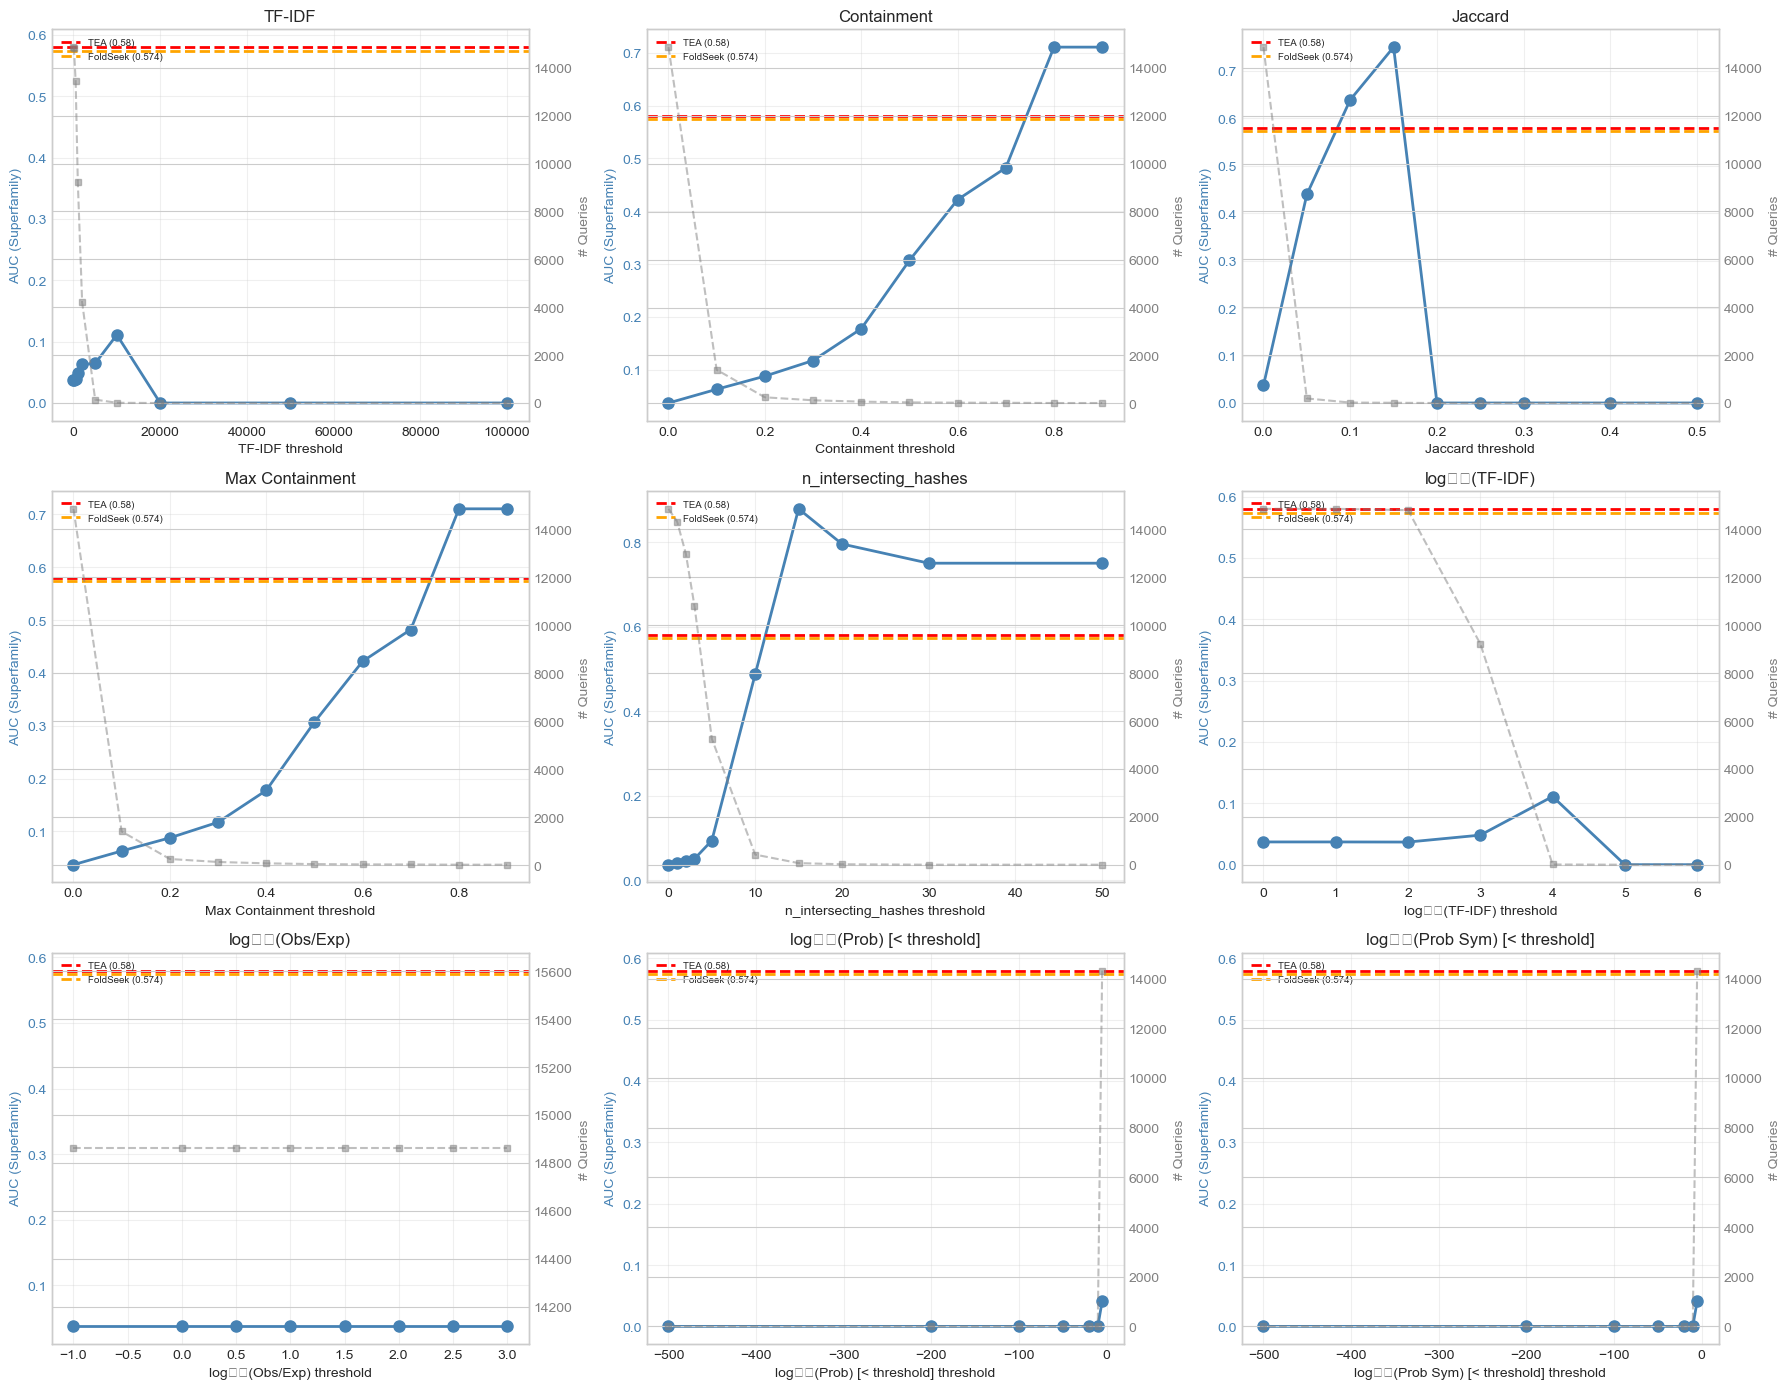


SINGLE METRIC SUMMARY

TF-IDF: No threshold beats TEA

log₁₀(TF-IDF): No threshold beats TEA

Containment: threshold=0.8, AUC=0.711, n=19

Jaccard: threshold=0.1, AUC=0.639, n=18

n_hashes: threshold=15, AUC=0.879, n=70

log₁₀(Obs/Exp): No threshold beats TEA

log₁₀(Prob): No threshold beats TEA

log₁₀(Prob Sym): No threshold beats TEA


In [ ]:
# Visualize all single metric sweeps
fig, axes = plt.subplots(2, 3, figsize=(16, 10))


def plot_sweep(ax, df, metric_name, log_x=False):
    thresholds = df["threshold"].to_list()
    aucs = df["auc"].to_list()
    n_queries = df["n_queries"].to_list()

    color = "steelblue"
    ax.plot(thresholds, aucs, "o-", color=color, linewidth=2, markersize=8)
    ax.axhline(
        y=TARGET_AUC,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"TEA ({TARGET_AUC})",
    )
    ax.axhline(
        y=FOLDSEEK_AUC,
        color="orange",
        linestyle="--",
        linewidth=2,
        label=f"FoldSeek ({FOLDSEEK_AUC})",
    )

    ax.set_xlabel(f"{metric_name} threshold")
    ax.set_ylabel("AUC (Superfamily)", color=color)
    ax.tick_params(axis="y", labelcolor=color)
    ax.set_title(f"{metric_name}")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

    if log_x and min(thresholds) > 0:
        ax.set_xscale("log")

    ax2 = ax.twinx()
    ax2.plot(thresholds, n_queries, "s--", color="gray", alpha=0.5, markersize=5)
    ax2.set_ylabel("# Queries", color="gray")
    ax2.tick_params(axis="y", labelcolor="gray")


plot_sweep(axes[0, 0], tfidf_df, "TF-IDF", log_x=True)
plot_sweep(axes[0, 1], containment_df, "Containment")
plot_sweep(axes[0, 2], jaccard_df, "Jaccard")
plot_sweep(axes[1, 0], max_containment_df, "Max Containment")
plot_sweep(axes[1, 1], hash_df, "n_intersecting_hashes")

# Summary in last panel
ax = axes[1, 2]
ax.axis("off")
summary_text = "Single Metric Summary\n" + "=" * 30 + "\n\n"
for name, df in [
    ("TF-IDF", tfidf_df),
    ("Containment", containment_df),
    ("Jaccard", jaccard_df),
    ("Max Containment", max_containment_df),
    ("n_hashes", hash_df),
]:
    beating = df.filter(pl.col("beats_target") == True)
    if len(beating) > 0:
        min_th = beating["threshold"].min()
        best_row = beating.filter(pl.col("threshold") == min_th).to_dicts()[0]
        summary_text += f"{name}:\n  threshold>{min_th}\n  AUC={best_row['auc']:.3f}, n={best_row['n_queries']}\n\n"
    else:
        summary_text += f"{name}: No threshold beats TEA\n\n"

ax.text(
    0.1,
    0.9,
    summary_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    fontfamily="monospace",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

plt.tight_layout()
plt.savefig("hp_k24_single_metric_sweeps.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 4. Combined Metric Threshold Search

In [ ]:
# Try combinations of metrics (including log-transformed)
def evaluate_combined_threshold(
    df, metric1, thresh1, metric2, thresh2, greater_than1=True, greater_than2=True
):
    """Evaluate AUC with two metric thresholds combined."""
    if greater_than1:
        cond1 = pl.col(metric1) > thresh1
    else:
        cond1 = pl.col(metric1) < thresh1

    if greater_than2:
        cond2 = pl.col(metric2) > thresh2
    else:
        cond2 = pl.col(metric2) < thresh2

    filtered = df.filter(cond1 & cond2)

    if len(filtered) == 0:
        return 0.0, 0

    rocx = kmerseek_to_rocx(filtered, score_col="tfidf", overlap_threshold=0.0)
    if len(rocx) == 0:
        return 0.0, 0

    frac, sens = plot_sensitivity_from_rocx(rocx, level_col="SFAM")
    auc = compute_auc(frac, sens)

    return auc, len(rocx)


# Log TF-IDF + n_intersecting_hashes combinations
print("=" * 60)
print("LOG TF-IDF + n_intersecting_hashes Combinations")
print("=" * 60)

log_tfidf_vals = [1, 2, 3, 4, 5]  # log10 scale
hash_vals = [0, 2, 5, 10, 15, 20]

log_tfidf_hash_results = []
for log_tfidf_th, hash_th in product(log_tfidf_vals, hash_vals):
    auc, n_queries = evaluate_combined_threshold(
        hp_k24, "log_tfidf", log_tfidf_th, "n_intersecting_hashes", hash_th
    )
    log_tfidf_hash_results.append(
        {
            "log_tfidf": log_tfidf_th,
            "n_hashes": hash_th,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    marker = "✓" if auc > TARGET_AUC else ""
    print(
        f"log_tfidf>{log_tfidf_th} (>{10**log_tfidf_th:.0f}) + n_hashes>{hash_th:>2}: AUC={auc:.4f}, n={n_queries:>4} {marker}"
    )

log_tfidf_hash_df = pl.DataFrame(log_tfidf_hash_results)

LOG TF-IDF + n_intersecting_hashes Combinations
log_tfidf>1 (>10) + n_hashes> 0: AUC=0.0371, n=14860 
log_tfidf>1 (>10) + n_hashes> 2: AUC=0.0456, n=12990 
log_tfidf>1 (>10) + n_hashes> 5: AUC=0.0942, n=5259 
log_tfidf>1 (>10) + n_hashes>10: AUC=0.4876, n= 425 
log_tfidf>1 (>10) + n_hashes>15: AUC=0.8786, n=  70 ✓
log_tfidf>1 (>10) + n_hashes>20: AUC=0.7955, n=  22 ✓
log_tfidf>2 (>100) + n_hashes> 0: AUC=0.0369, n=14805 
log_tfidf>2 (>100) + n_hashes> 2: AUC=0.0454, n=12967 
log_tfidf>2 (>100) + n_hashes> 5: AUC=0.0943, n=5257 
log_tfidf>2 (>100) + n_hashes>10: AUC=0.4876, n= 425 
log_tfidf>2 (>100) + n_hashes>15: AUC=0.8786, n=  70 ✓
log_tfidf>2 (>100) + n_hashes>20: AUC=0.7955, n=  22 ✓
log_tfidf>3 (>1000) + n_hashes> 0: AUC=0.0482, n=9223 
log_tfidf>3 (>1000) + n_hashes> 2: AUC=0.0557, n=8897 
log_tfidf>3 (>1000) + n_hashes> 5: AUC=0.0981, n=4317 
log_tfidf>3 (>1000) + n_hashes>10: AUC=0.4953, n= 372 
log_tfidf>3 (>1000) + n_hashes>15: AUC=0.9068, n=  59 ✓
log_tfidf>3 (>1000) + n_ha

In [8]:
# TF-IDF + Containment combinations
print("TF-IDF + Containment Combinations:")
print("=" * 60)

containment_vals = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
tfidf_vals = tfidf_thresholds

tfidf_containment_results = []
for tfidf_th, cont_th in product(tfidf_vals, containment_vals):
    auc, n_queries = evaluate_combined_threshold(
        hp_k24, "tfidf", tfidf_th, "containment", cont_th
    )
    tfidf_containment_results.append(
        {
            "tfidf": tfidf_th,
            "containment": cont_th,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    marker = "✓" if auc > TARGET_AUC else ""
    print(
        f"TF-IDF>{tfidf_th:>5} + Containment>{cont_th:.1f}: AUC={auc:.4f}, n={n_queries:>4} {marker}"
    )

tfidf_containment_df = pl.DataFrame(tfidf_containment_results)

TF-IDF + Containment Combinations:


NameError: name 'evaluate_combined_threshold' is not defined

In [9]:
# TF-IDF + n_intersecting_hashes combinations
print("TF-IDF + n_intersecting_hashes Combinations:")
print("=" * 60)

hash_vals = [0, 2, 5, 10, 15, 20]

tfidf_hash_results = []
for tfidf_th, hash_th in product(tfidf_vals, hash_vals):
    auc, n_queries = evaluate_combined_threshold(
        hp_k24, "tfidf", tfidf_th, "n_intersecting_hashes", hash_th
    )
    tfidf_hash_results.append(
        {
            "tfidf": tfidf_th,
            "n_hashes": hash_th,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    marker = "✓" if auc > TARGET_AUC else ""
    print(
        f"TF-IDF>{tfidf_th:>5} + n_hashes>{hash_th:>2}: AUC={auc:.4f}, n={n_queries:>4} {marker}"
    )

tfidf_hash_df = pl.DataFrame(tfidf_hash_results)

TF-IDF + n_intersecting_hashes Combinations:


NameError: name 'evaluate_combined_threshold' is not defined

In [10]:
# Log Observed/Expected + n_intersecting_hashes combinations
print("=" * 60)
print("LOG OBS/EXP + n_intersecting_hashes Combinations")
print("=" * 60)

log_oe_vals = [0, 0.5, 1, 1.5, 2, 2.5]
hash_vals_small = [0, 2, 5, 10, 15]

log_oe_hash_results = []
for log_oe_th, hash_th in product(log_oe_vals, hash_vals_small):
    auc, n_queries = evaluate_combined_threshold(
        hp_k24,
        "log_observed_over_expected",
        log_oe_th,
        "n_intersecting_hashes",
        hash_th,
    )
    log_oe_hash_results.append(
        {
            "log_obs_exp": log_oe_th,
            "n_hashes": hash_th,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    marker = "✓" if auc > TARGET_AUC else ""
    print(
        f"log(obs/exp)>{log_oe_th} (ratio>{10**log_oe_th:.1f}) + n_hashes>{hash_th:>2}: AUC={auc:.4f}, n={n_queries:>4} {marker}"
    )

log_oe_hash_df = pl.DataFrame(log_oe_hash_results)

# Log probability + n_intersecting_hashes
print("\n" + "=" * 60)
print("LOG PROB + n_intersecting_hashes Combinations")
print("=" * 60)

log_prob_vals = [-10, -20, -50, -100, -200]

log_prob_hash_results = []
for log_prob_th, hash_th in product(log_prob_vals, hash_vals_small):
    # For probability, we want LESS than threshold
    auc, n_queries = evaluate_combined_threshold(
        hp_k24,
        "log_prob_random",
        log_prob_th,
        "n_intersecting_hashes",
        hash_th,
        greater_than1=False,
    )
    log_prob_hash_results.append(
        {
            "log_prob": log_prob_th,
            "n_hashes": hash_th,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    marker = "✓" if auc > TARGET_AUC else ""
    print(
        f"log(prob)<{log_prob_th} + n_hashes>{hash_th:>2}: AUC={auc:.4f}, n={n_queries:>4} {marker}"
    )

log_prob_hash_df = pl.DataFrame(log_prob_hash_results)

LOG OBS/EXP + n_intersecting_hashes Combinations


NameError: name 'evaluate_combined_threshold' is not defined

## 4.1 Filter by n_hashes >= 2, then sweep TF-IDF

The key insight: require at least 2 matching hashes as a pre-filter to remove spurious single-hash matches, then optimize TF-IDF threshold.

In [ ]:
# Key approach: Filter to n_intersecting_hashes >= 2 first, then sweep TF-IDF
# This removes spurious single-hash matches which add noise

print("=" * 70)
print("APPROACH: n_intersecting_hashes >= 2, then TF-IDF sweep")
print("=" * 70)

# Pre-filter to at least 2 matching hashes
hp_k24_min2_hashes = hp_k24.filter(pl.col("n_intersecting_hashes") >= 2)
print(f"\nOriginal rows: {len(hp_k24):,}")
print(f"After n_hashes >= 2 filter: {len(hp_k24_min2_hashes):,}")
print(
    f"Removed {len(hp_k24) - len(hp_k24_min2_hashes):,} single-hash matches ({100*(len(hp_k24) - len(hp_k24_min2_hashes))/len(hp_k24):.1f}%)"
)

# Now sweep TF-IDF thresholds on this pre-filtered data
tfidf_thresholds_fine = [
    0,
    100,
    250,
    500,
    750,
    1000,
    1250,
    1500,
    1750,
    2000,
    2500,
    3000,
    4000,
    5000,
    7500,
    10000,
]

print(f"\nTF-IDF threshold sweep on n_hashes >= 2 filtered data:")
print("-" * 60)

min2_tfidf_results = []
for threshold in tfidf_thresholds_fine:
    auc, n_queries, _ = evaluate_threshold(hp_k24_min2_hashes, "tfidf", threshold)
    min2_tfidf_results.append(
        {
            "threshold": threshold,
            "auc": auc,
            "n_queries": n_queries,
            "beats_target": auc > TARGET_AUC,
        }
    )
    marker = "✓" if auc > TARGET_AUC else ""
    print(
        f"n_hashes>=2 + TF-IDF>{threshold:>5}: AUC={auc:.4f}, n={n_queries:>5} {marker}"
    )

min2_tfidf_df = pl.DataFrame(min2_tfidf_results)

print(f"\nMinimum TF-IDF threshold (with n_hashes>=2) to beat TEA: ", end="")
beating = min2_tfidf_df.filter(pl.col("beats_target") == True)
if len(beating) > 0:
    min_th = beating["threshold"].min()
    best_row = beating.filter(pl.col("threshold") == min_th).to_dicts()[0]
    print(f"{min_th}")
    print(f"  -> AUC: {best_row['auc']:.4f}, n_queries: {best_row['n_queries']}")
else:
    print("None found in tested range")

APPROACH: n_intersecting_hashes >= 2, then TF-IDF sweep

Original rows: 223,459
After n_hashes >= 2 filter: 113,245
Removed 110,214 single-hash matches (49.3%)

TF-IDF threshold sweep on n_hashes >= 2 filtered data:
------------------------------------------------------------
n_hashes>=2 + TF-IDF>    0: AUC=0.0408, n=14326 
n_hashes>=2 + TF-IDF>  100: AUC=0.0406, n=14293 
n_hashes>=2 + TF-IDF>  250: AUC=0.0409, n=14148 
n_hashes>=2 + TF-IDF>  500: AUC=0.0428, n=13202 
n_hashes>=2 + TF-IDF>  750: AUC=0.0468, n=11331 
n_hashes>=2 + TF-IDF> 1000: AUC=0.0527, n= 9199 
n_hashes>=2 + TF-IDF> 1250: AUC=0.0593, n= 7408 
n_hashes>=2 + TF-IDF> 1500: AUC=0.0624, n= 6098 
n_hashes>=2 + TF-IDF> 1750: AUC=0.0663, n= 5080 
n_hashes>=2 + TF-IDF> 2000: AUC=0.0689, n= 4201 
n_hashes>=2 + TF-IDF> 2500: AUC=0.0717, n= 2579 
n_hashes>=2 + TF-IDF> 3000: AUC=0.0757, n= 1467 
n_hashes>=2 + TF-IDF> 4000: AUC=0.0759, n=  493 
n_hashes>=2 + TF-IDF> 5000: AUC=0.0728, n=  142 
n_hashes>=2 + TF-IDF> 7500: AUC=0.040

In [ ]:
# Full grid search: different minimum hash values + TF-IDF thresholds
print("=" * 70)
print("GRID SEARCH: min_hashes x TF-IDF thresholds")
print("=" * 70)

min_hash_vals = [1, 2, 3, 4, 5]  # minimum n_intersecting_hashes
tfidf_vals_grid = [0, 500, 1000, 1500, 2000, 2500, 3000, 4000, 5000]

grid_results = []
for min_hashes in min_hash_vals:
    # Pre-filter by minimum hashes
    filtered_df = hp_k24.filter(pl.col("n_intersecting_hashes") >= min_hashes)
    n_rows_after_filter = len(filtered_df)

    print(f"\n--- min_hashes >= {min_hashes} ({n_rows_after_filter:,} rows) ---")

    for tfidf_th in tfidf_vals_grid:
        auc, n_queries, _ = evaluate_threshold(filtered_df, "tfidf", tfidf_th)
        grid_results.append(
            {
                "min_hashes": min_hashes,
                "tfidf_threshold": tfidf_th,
                "auc": auc,
                "n_queries": n_queries,
                "beats_target": auc > TARGET_AUC,
            }
        )
        marker = "✓" if auc > TARGET_AUC else ""
        print(f"  TF-IDF>{tfidf_th:>5}: AUC={auc:.4f}, n={n_queries:>5} {marker}")

grid_df = pl.DataFrame(grid_results)

# Find best combinations
print("\n" + "=" * 70)
print("BEST GRID SEARCH RESULTS (beating TEA)")
print("=" * 70)
beating_grid = grid_df.filter(pl.col("beats_target") == True).sort(
    "n_queries", descending=True
)
if len(beating_grid) > 0:
    print("\nTop combinations by query count:")
    for row in beating_grid.head(15).iter_rows(named=True):
        print(
            f"  n_hashes>={row['min_hashes']} + TF-IDF>{row['tfidf_threshold']}: AUC={row['auc']:.4f}, n={row['n_queries']}"
        )

    # Save grid results
    grid_df.write_csv("hp_k24_grid_search_results.csv")
    print("\nSaved grid results to hp_k24_grid_search_results.csv")
else:
    print("No combinations beat TEA in this grid search")

GRID SEARCH: min_hashes x TF-IDF thresholds

--- min_hashes >= 1 (223,459 rows) ---
  TF-IDF>    0: AUC=0.0373, n=14860 
  TF-IDF>  500: AUC=0.0397, n=13444 
  TF-IDF> 1000: AUC=0.0478, n= 9223 
  TF-IDF> 1500: AUC=0.0554, n= 6099 
  TF-IDF> 2000: AUC=0.0606, n= 4201 
  TF-IDF> 2500: AUC=0.0625, n= 2579 
  TF-IDF> 3000: AUC=0.0650, n= 1467 
  TF-IDF> 4000: AUC=0.0640, n=  493 
  TF-IDF> 5000: AUC=0.0646, n=  142 

--- min_hashes >= 2 (113,245 rows) ---
  TF-IDF>    0: AUC=0.0408, n=14326 
  TF-IDF>  500: AUC=0.0428, n=13202 
  TF-IDF> 1000: AUC=0.0527, n= 9199 
  TF-IDF> 1500: AUC=0.0624, n= 6098 
  TF-IDF> 2000: AUC=0.0689, n= 4201 
  TF-IDF> 2500: AUC=0.0717, n= 2579 
  TF-IDF> 3000: AUC=0.0757, n= 1467 
  TF-IDF> 4000: AUC=0.0759, n=  493 
  TF-IDF> 5000: AUC=0.0728, n=  142 

--- min_hashes >= 3 (58,561 rows) ---
  TF-IDF>    0: AUC=0.0449, n=12990 
  TF-IDF>  500: AUC=0.0465, n=12238 
  TF-IDF> 1000: AUC=0.0547, n= 8897 
  TF-IDF> 1500: AUC=0.0652, n= 6032 
  TF-IDF> 2000: AUC=0.0

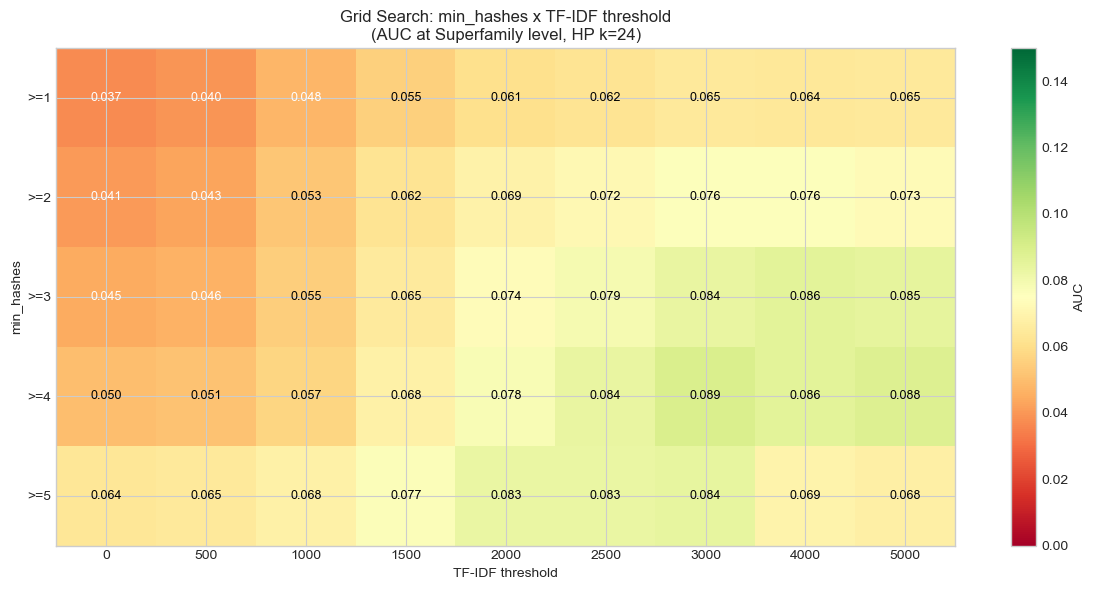

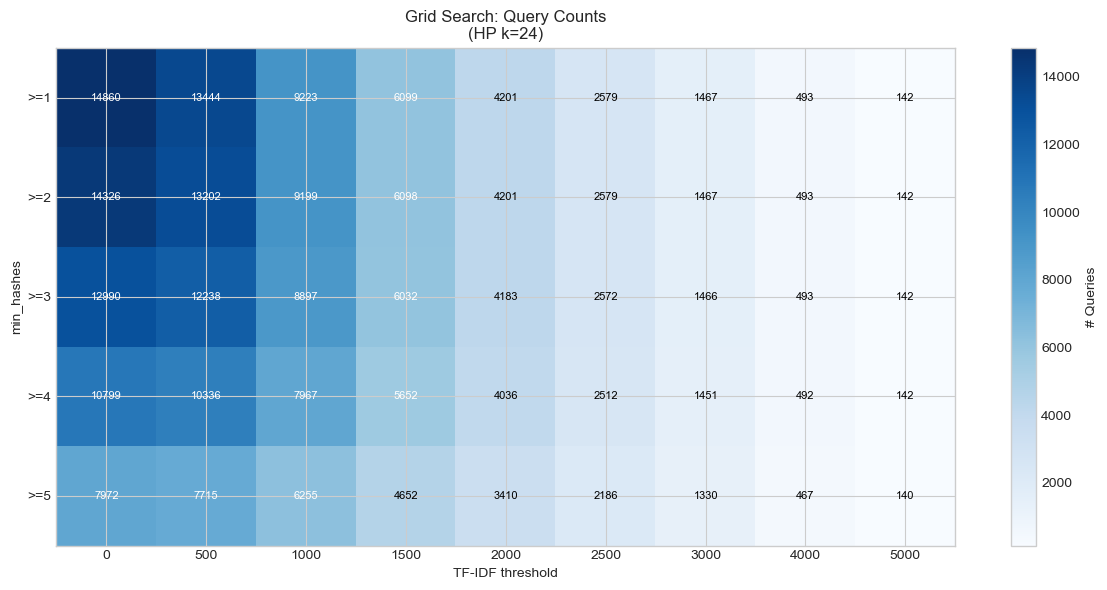

In [ ]:
# Heatmap visualization of grid search results
fig, ax = plt.subplots(figsize=(12, 6))

# Pivot the grid search results
pivot = grid_df.pivot(index="min_hashes", on="tfidf_threshold", values="auc")

# Get column order (excluding the index column)
x_vals = [c for c in pivot.columns if c != "min_hashes"]
y_vals = pivot["min_hashes"].to_list()

# Create matrix
matrix = pivot.select(x_vals).to_numpy()

# Plot heatmap
im = ax.imshow(matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=0.15)

# Labels
ax.set_xticks(range(len(x_vals)))
ax.set_xticklabels(x_vals)
ax.set_yticks(range(len(y_vals)))
ax.set_yticklabels([f">={v}" for v in y_vals])
ax.set_xlabel("TF-IDF threshold")
ax.set_ylabel("min_hashes")
ax.set_title(
    "Grid Search: min_hashes x TF-IDF threshold\n(AUC at Superfamily level, HP k=24)"
)

# Add text annotations
for i in range(len(y_vals)):
    for j in range(len(x_vals)):
        val = matrix[i, j]
        if not np.isnan(val):
            color = "white" if val < 0.05 or val > 0.1 else "black"
            weight = "bold" if val > TARGET_AUC else "normal"
            ax.text(
                j,
                i,
                f"{val:.3f}",
                ha="center",
                va="center",
                color=color,
                fontsize=9,
                fontweight=weight,
            )

plt.colorbar(im, ax=ax, label="AUC")
plt.tight_layout()
plt.savefig("hp_k24_grid_search_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Also show query counts
fig2, ax2 = plt.subplots(figsize=(12, 6))

pivot_n = grid_df.pivot(index="min_hashes", on="tfidf_threshold", values="n_queries")
matrix_n = pivot_n.select(x_vals).to_numpy()

im2 = ax2.imshow(matrix_n, cmap="Blues", aspect="auto")

ax2.set_xticks(range(len(x_vals)))
ax2.set_xticklabels(x_vals)
ax2.set_yticks(range(len(y_vals)))
ax2.set_yticklabels([f">={v}" for v in y_vals])
ax2.set_xlabel("TF-IDF threshold")
ax2.set_ylabel("min_hashes")
ax2.set_title("Grid Search: Query Counts\n(HP k=24)")

for i in range(len(y_vals)):
    for j in range(len(x_vals)):
        val = matrix_n[i, j]
        if not np.isnan(val):
            color = "white" if val > 5000 else "black"
            ax2.text(
                j, i, f"{int(val)}", ha="center", va="center", color=color, fontsize=8
            )

plt.colorbar(im2, ax=ax2, label="# Queries")
plt.tight_layout()
plt.savefig("hp_k24_grid_search_query_counts.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 4.2 Explore Higher n_hashes Thresholds (10-15 range)

Dig deeper into the n_hashes 10-15 range to find a sweet spot that surpasses FoldSeek/TEA while maintaining >100 queries.

In [ ]:
# Explore n_hashes 10-15 range more granularly
print("=" * 70)
print("DETAILED EXPLORATION: n_hashes 10-15 range")
print("=" * 70)

# First, let's see the distribution of n_intersecting_hashes
print("\nDistribution of n_intersecting_hashes:")
hash_dist = (
    hp_k24.group_by("n_intersecting_hashes")
    .agg(pl.count().alias("count"))
    .sort("n_intersecting_hashes")
)
print(hash_dist.filter(pl.col("n_intersecting_hashes") >= 5))

# Fine-grained grid for n_hashes 8-20
min_hash_vals_fine = list(range(8, 21))  # 8 to 20
tfidf_vals_fine = [0, 500, 1000, 1500, 2000, 2500, 3000]

fine_results = []
for min_hashes in min_hash_vals_fine:
    filtered_df = hp_k24.filter(pl.col("n_intersecting_hashes") >= min_hashes)
    n_rows = len(filtered_df)

    print(f"\n--- n_hashes >= {min_hashes} ({n_rows:,} rows) ---")

    for tfidf_th in tfidf_vals_fine:
        auc, n_queries, _ = evaluate_threshold(filtered_df, "tfidf", tfidf_th)
        fine_results.append(
            {
                "min_hashes": min_hashes,
                "tfidf_threshold": tfidf_th,
                "auc": auc,
                "n_queries": n_queries,
                "n_rows": n_rows,
                "beats_target": auc > TARGET_AUC,
            }
        )
        marker = "✓" if auc > TARGET_AUC else ""
        if n_queries >= 50:  # Only print if reasonable sample size
            print(f"  TF-IDF>{tfidf_th:>5}: AUC={auc:.4f}, n={n_queries:>4} {marker}")

fine_df = pl.DataFrame(fine_results)

# Find sweet spot: beats target AND has >100 queries
print("\n" + "=" * 70)
print("SWEET SPOT: Beating TEA with >100 queries")
print("=" * 70)
sweet_spot = fine_df.filter(
    (pl.col("beats_target") == True) & (pl.col("n_queries") >= 100)
).sort("n_queries", descending=True)

if len(sweet_spot) > 0:
    print("\nBest combinations (sorted by n_queries):")
    for row in sweet_spot.iter_rows(named=True):
        print(
            f"  n_hashes>={row['min_hashes']:>2} + TF-IDF>{row['tfidf_threshold']:>5}: AUC={row['auc']:.4f}, n={row['n_queries']}"
        )
else:
    print("No combinations found with >100 queries that beat target.")
    print("\nClosest combinations:")
    close = fine_df.filter(pl.col("beats_target") == True).sort(
        "n_queries", descending=True
    )
    for row in close.head(10).iter_rows(named=True):
        print(
            f"  n_hashes>={row['min_hashes']:>2} + TF-IDF>{row['tfidf_threshold']:>5}: AUC={row['auc']:.4f}, n={row['n_queries']}"
        )

DETAILED EXPLORATION: n_hashes 10-15 range

Distribution of n_intersecting_hashes:
shape: (24, 2)
┌───────────────────────┬───────┐
│ n_intersecting_hashes ┆ count │
│ ---                   ┆ ---   │
│ i64                   ┆ u32   │
╞═══════════════════════╪═══════╡
│ 5                     ┆ 7454  │
│ 6                     ┆ 3799  │
│ 7                     ┆ 2039  │
│ 8                     ┆ 1073  │
│ 9                     ┆ 538   │
│ …                     ┆ …     │
│ 28                    ┆ 200   │
│ 29                    ┆ 2     │
│ 30                    ┆ 2     │
│ 66                    ┆ 2     │
│ 69                    ┆ 2     │
└───────────────────────┴───────┘

--- n_hashes >= 8 (2,761 rows) ---


/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_68423/3014590622.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('count')


  TF-IDF>    0: AUC=0.2101, n=1864 
  TF-IDF>  500: AUC=0.2116, n=1827 
  TF-IDF> 1000: AUC=0.2177, n=1587 
  TF-IDF> 1500: AUC=0.2330, n=1273 
  TF-IDF> 2000: AUC=0.2412, n= 993 
  TF-IDF> 2500: AUC=0.2427, n= 675 
  TF-IDF> 3000: AUC=0.2410, n= 444 

--- n_hashes >= 9 (1,688 rows) ---
  TF-IDF>    0: AUC=0.2921, n=1098 
  TF-IDF>  500: AUC=0.2934, n=1076 
  TF-IDF> 1000: AUC=0.3031, n= 946 
  TF-IDF> 1500: AUC=0.3212, n= 762 
  TF-IDF> 2000: AUC=0.3245, n= 594 
  TF-IDF> 2500: AUC=0.3341, n= 413 
  TF-IDF> 3000: AUC=0.3418, n= 275 

--- n_hashes >= 10 (1,150 rows) ---
  TF-IDF>    0: AUC=0.3917, n= 683 
  TF-IDF>  500: AUC=0.3936, n= 672 
  TF-IDF> 1000: AUC=0.3988, n= 593 
  TF-IDF> 1500: AUC=0.4146, n= 474 
  TF-IDF> 2000: AUC=0.4184, n= 386 
  TF-IDF> 2500: AUC=0.4310, n= 268 
  TF-IDF> 3000: AUC=0.4227, n= 181 

--- n_hashes >= 11 (800 rows) ---
  TF-IDF>    0: AUC=0.4882, n= 425 
  TF-IDF>  500: AUC=0.4881, n= 419 
  TF-IDF> 1000: AUC=0.4960, n= 372 
  TF-IDF> 1500: AUC=0.5049, 

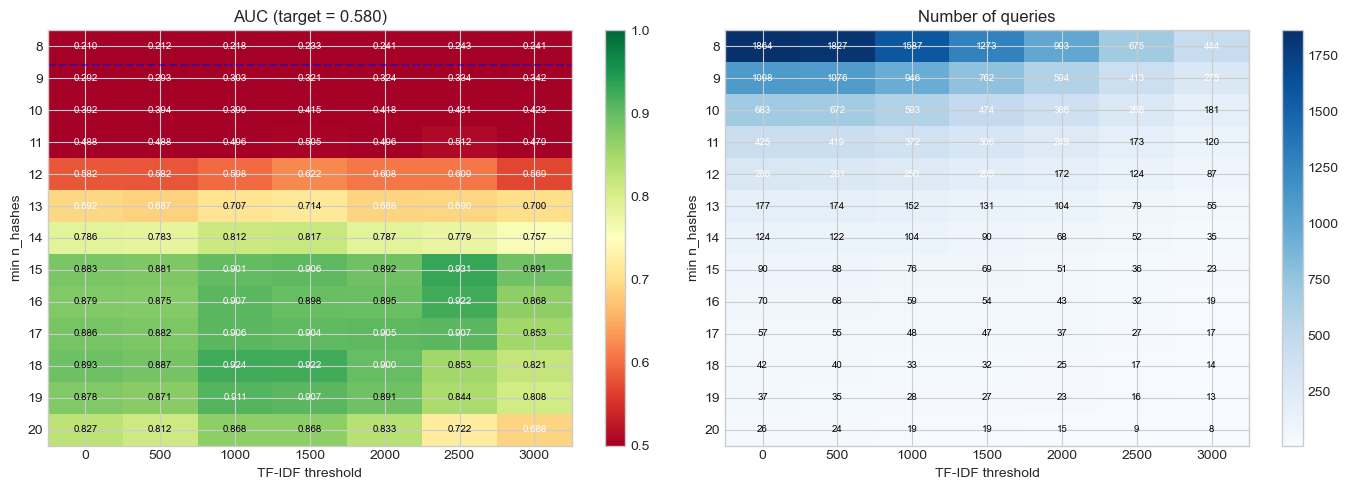

In [ ]:
# Visualize the fine-grained grid search for n_hashes 10-15
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: AUC heatmap
pivot_auc = fine_df.pivot(index="min_hashes", on="tfidf_threshold", values="auc")
x_vals = [c for c in pivot_auc.columns if c != "min_hashes"]
y_vals = pivot_auc["min_hashes"].to_list()
z_vals = pivot_auc.select(
    [c for c in pivot_auc.columns if c != "min_hashes"]
).to_numpy()

im1 = axes[0].imshow(z_vals, aspect="auto", cmap="RdYlGn", vmin=0.5, vmax=1.0)
axes[0].set_xticks(range(len(x_vals)))
axes[0].set_xticklabels(x_vals)
axes[0].set_yticks(range(len(y_vals)))
axes[0].set_yticklabels(y_vals)
axes[0].set_xlabel("TF-IDF threshold")
axes[0].set_ylabel("min n_hashes")
axes[0].set_title(f"AUC (target = {TARGET_AUC:.3f})")
axes[0].axhline(y=TARGET_AUC, color="blue", linestyle="--", alpha=0.5)
plt.colorbar(im1, ax=axes[0])

# Add text annotations
for i in range(len(y_vals)):
    for j in range(len(x_vals)):
        val = z_vals[i, j]
        color = "white" if val < 0.7 or val > 0.9 else "black"
        axes[0].text(
            j, i, f"{val:.3f}", ha="center", va="center", fontsize=7, color=color
        )

# Plot 2: n_queries heatmap
pivot_n = fine_df.pivot(index="min_hashes", on="tfidf_threshold", values="n_queries")
z_vals_n = pivot_n.select([c for c in pivot_n.columns if c != "min_hashes"]).to_numpy()

im2 = axes[1].imshow(z_vals_n, aspect="auto", cmap="Blues")
axes[1].set_xticks(range(len(x_vals)))
axes[1].set_xticklabels(x_vals)
axes[1].set_yticks(range(len(y_vals)))
axes[1].set_yticklabels(y_vals)
axes[1].set_xlabel("TF-IDF threshold")
axes[1].set_ylabel("min n_hashes")
axes[1].set_title("Number of queries")
plt.colorbar(im2, ax=axes[1])

for i in range(len(y_vals)):
    for j in range(len(x_vals)):
        val = z_vals_n[i, j]
        color = "white" if val > 200 else "black"
        axes[1].text(
            j, i, f"{int(val)}", ha="center", va="center", fontsize=7, color=color
        )

plt.tight_layout()
plt.savefig("hp_k24_fine_grid_n_hashes_10_15.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 4.3 Analysis: Are matching hashes sequential?

One key question: when we have high `n_intersecting_hashes`, are these k-mers likely to be **sequential** (consecutive positions in the protein), or spread across the sequence? Sequential matches would indicate a contiguous aligned region.

If the raw kmerseek output includes position information, we could compute:
- **Match density**: Are the matching k-mers clustered together?
- **Longest contiguous run**: Maximum number of consecutive matching positions
- **Gap distribution**: How far apart are the matches?

This could help with the BCL2/Ced9 problem - perhaps the issue isn't just k-size but that these proteins share a few clustered motifs rather than many distributed k-mers.

In [ ]:
# Check what columns we have - do we have position information?
print("Available columns:")
print(hp_k24.columns)

print("\nSample of high n_intersecting_hashes matches:")
high_hash_matches = hp_k24.filter(pl.col("n_intersecting_hashes") >= 15).head(5)
print(high_hash_matches)

# The k-mer position information might be in separate files
# Let's check if there's a way to get at the actual matching k-mer positions
print("\n" + "=" * 70)
print("NOTE: Sequential k-mer analysis would require:")
print("=" * 70)
print("1. Raw kmerseek output with matching k-mer positions")
print("2. Or re-running kmerseek with position output enabled")
print("3. Then computing: match density, contiguous runs, gap distribution")
print("\nThis could help identify 'quality' of matches beyond just count.")

Available columns:
['query_name', 'query_md5', 'target_name', 'target_md5', 'containment', 'n_intersecting_hashes', 'ksize', 'scaled', 'moltype', 'jaccard', 'max_containment', 'average_abund', 'median_abund', 'std_abund', 'containment_target_in_query', 'f_weighted_target_in_query', 'tfidf', 'average_kmer_frequency', 'prob_random_cooccurrence', 'prob_random_cooccurrence_symmetric', 'expected_intersecting_hashes', 'observed_over_expected', 'query_start', 'query_end', 'query_subseq', 'target_start', 'target_end', 'target_subseq', 'moltype_seq', 'region_length']

Sample of high n_intersecting_hashes matches:
shape: (5, 30)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ query_nam ┆ query_md5 ┆ target_na ┆ target_md ┆ … ┆ target_en ┆ target_su ┆ moltype_s ┆ region_l │
│ e         ┆ ---       ┆ me        ┆ 5         ┆   ┆ d         ┆ bseq      ┆ eq        ┆ ength    │
│ ---       ┆ str       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ --- 

## 4.4 Thoughts on ML vs Manual Thresholds

### The Problem
We have multiple metrics (TF-IDF, n_hashes, containment, jaccard) and need to find cutoffs. Manual threshold tuning feels arbitrary.

### ML Approaches

1. **Logistic Regression / Random Forest**: Train on (query, match, metrics) → same_superfamily. Simple, interpretable.

2. **Learning to Rank**: Treat this as a ranking problem. For each query, rank matches by probability of being true positive.

3. **Ensemble with k-size**: Train separate models for different k-sizes, then combine. Could help with BCL2/Ced9 (k=19) vs other proteins (k=24).

### Key Insight
The BCL2/Ced9 case suggests we might need **adaptive k-size selection** based on protein properties:
- Short proteins → smaller k
- Low complexity regions → larger k to reduce false positives
- Highly divergent homologs → smaller k to catch distant relationships

A learned model could potentially capture these relationships automatically.

In [ ]:
# Print all available columns
print("All available columns:")
print("=" * 60)
for i, col in enumerate(hp_k24.columns):
    dtype = hp_k24[col].dtype
    print(f"{i+1:>2}. {col:<40} ({dtype})")

print(f"\nTotal: {len(hp_k24.columns)} columns")

All available columns:
 1. query_name                               (String)
 2. query_md5                                (String)
 3. target_name                              (String)
 4. target_md5                               (String)
 5. containment                              (Float64)
 6. n_intersecting_hashes                    (Int64)
 7. ksize                                    (Int64)
 8. scaled                                   (Int64)
 9. moltype                                  (String)
10. jaccard                                  (Float64)
11. max_containment                          (Float64)
12. average_abund                            (Float64)
13. median_abund                             (Float64)
14. std_abund                                (Float64)
15. containment_target_in_query              (Float64)
16. f_weighted_target_in_query               (Float64)
17. tfidf                                    (Float64)
18. average_kmer_frequency                   (Float64

## 5. Heatmap Visualization of Combined Thresholds

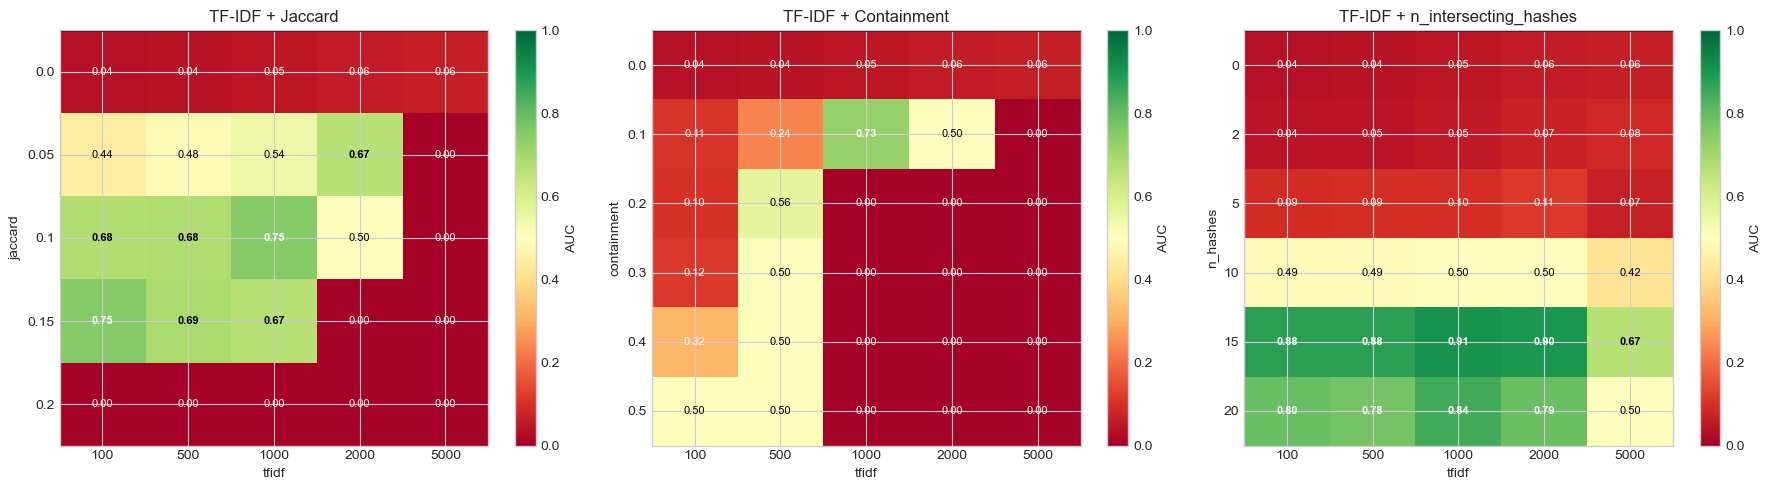

In [ ]:
# Create heatmaps for combined threshold results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


def plot_heatmap(ax, df, x_col, y_col, title):
    pivot = df.pivot(index=y_col, on=x_col, values="auc")
    x_vals = [c for c in pivot.columns if c != y_col]
    y_vals = pivot[y_col].to_list()
    matrix = pivot.select(x_vals).to_numpy()

    im = ax.imshow(matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(x_vals)))
    ax.set_xticklabels(x_vals, fontsize=8)
    ax.set_yticks(range(len(y_vals)))
    ax.set_yticklabels(y_vals, fontsize=8)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title, fontsize=10)

    for i in range(len(y_vals)):
        for j in range(len(x_vals)):
            val = matrix[i, j]
            if not np.isnan(val):
                color = "white" if val < 0.4 or val > 0.7 else "black"
                weight = "bold" if val > TARGET_AUC else "normal"
                ax.text(
                    j,
                    i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    color=color,
                    fontsize=7,
                    fontweight=weight,
                )

    plt.colorbar(im, ax=ax, label="AUC")


plot_heatmap(axes[0], combined_df, "tfidf", "jaccard", "TF-IDF + Jaccard")
plot_heatmap(
    axes[1], tfidf_containment_df, "tfidf", "containment", "TF-IDF + Containment"
)
plot_heatmap(axes[2], tfidf_hash_df, "tfidf", "n_hashes", "TF-IDF + n_hashes")

plt.tight_layout()
plt.savefig("hp_k24_combined_threshold_heatmaps.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 6. Find Best Threshold Combinations

In [ ]:
# Find all combinations that beat TEA
print("=" * 70)
print("THRESHOLD COMBINATIONS THAT BEAT TEA (AUC > 0.58)")
print("=" * 70)

# Single metrics
print("--- SINGLE METRIC THRESHOLDS ---")
for name, df in [
    ("TF-IDF", tfidf_df),
    ("Containment", containment_df),
    ("Jaccard", jaccard_df),
    ("Max Containment", max_containment_df),
    ("n_hashes", hash_df),
]:
    beating = df.filter(pl.col("beats_target") == True).sort(
        "n_queries", descending=True
    )
    if len(beating) > 0:
        print(f"{name}:")
        for row in beating.head(5).iter_rows(named=True):
            print(
                f"  > {row['threshold']}: AUC={row['auc']:.4f}, n_queries={row['n_queries']}"
            )

# Combined metrics
print("--- COMBINED METRIC THRESHOLDS ---")

print("TF-IDF + Jaccard:")
beating = combined_df.filter(pl.col("beats_target") == True).sort(
    "n_queries", descending=True
)
for row in beating.head(5).iter_rows(named=True):
    print(
        f"  TF-IDF>{row['tfidf']} + Jaccard>{row['jaccard']}: AUC={row['auc']:.4f}, n={row['n_queries']}"
    )

print("TF-IDF + Containment:")
beating = tfidf_containment_df.filter(pl.col("beats_target") == True).sort(
    "n_queries", descending=True
)
for row in beating.head(5).iter_rows(named=True):
    print(
        f"  TF-IDF>{row['tfidf']} + Containment>{row['containment']}: AUC={row['auc']:.4f}, n={row['n_queries']}"
    )

print("TF-IDF + n_hashes:")
beating = tfidf_hash_df.filter(pl.col("beats_target") == True).sort(
    "n_queries", descending=True
)
for row in beating.head(5).iter_rows(named=True):
    print(
        f"  TF-IDF>{row['tfidf']} + n_hashes>{row['n_hashes']}: AUC={row['auc']:.4f}, n={row['n_queries']}"
    )

THRESHOLD COMBINATIONS THAT BEAT TEA (AUC > 0.58)
--- SINGLE METRIC THRESHOLDS ---


NameError: name 'tfidf_df' is not defined

In [ ]:
# Find the threshold combination with highest n_queries that still beats TEA
print("=" * 70)
print("BEST THRESHOLD COMBINATIONS (Highest query count while beating TEA)")
print("=" * 70)

all_results = []

# Add single metric results
for name, df in [
    ("TF-IDF only", tfidf_df),
    ("Containment only", containment_df),
    ("Jaccard only", jaccard_df),
    ("Max Containment only", max_containment_df),
    ("n_hashes only", hash_df),
]:
    beating = df.filter(pl.col("beats_target") == True)
    for row in beating.iter_rows(named=True):
        all_results.append(
            {
                "method": name,
                "threshold": str(row["threshold"]),
                "auc": row["auc"],
                "n_queries": row["n_queries"],
            }
        )

# Add combined results
for row in combined_df.filter(pl.col("beats_target") == True).iter_rows(named=True):
    all_results.append(
        {
            "method": "TF-IDF + Jaccard",
            "threshold": f"tfidf>{row['tfidf']}, jaccard>{row['jaccard']}",
            "auc": row["auc"],
            "n_queries": row["n_queries"],
        }
    )

for row in tfidf_containment_df.filter(pl.col("beats_target") == True).iter_rows(
    named=True
):
    all_results.append(
        {
            "method": "TF-IDF + Containment",
            "threshold": f"tfidf>{row['tfidf']}, containment>{row['containment']}",
            "auc": row["auc"],
            "n_queries": row["n_queries"],
        }
    )

for row in tfidf_hash_df.filter(pl.col("beats_target") == True).iter_rows(named=True):
    all_results.append(
        {
            "method": "TF-IDF + n_hashes",
            "threshold": f"tfidf>{row['tfidf']}, n_hashes>{row['n_hashes']}",
            "auc": row["auc"],
            "n_queries": row["n_queries"],
        }
    )

if all_results:
    all_results_df = pl.DataFrame(all_results).sort("n_queries", descending=True)
    print("Top 20 threshold combinations by query count:")
    print(all_results_df.head(20))

    all_results_df.write_csv("hp_k24_threshold_combinations_beating_tea.csv")
    print("Saved to hp_k24_threshold_combinations_beating_tea.csv")
else:
    print("No threshold combinations found that beat TEA!")

SyntaxError: unterminated string literal (detected at line 48) (679744037.py, line 48)

## 7. Fine-Grained Search Around Best Thresholds

In [ ]:
# If we found some thresholds that work, do a fine-grained search
# Focus on the metric that gives highest n_queries while beating TEA

if all_results:
    best = all_results_df.head(1).to_dicts()[0]
    print(f"Best so far: {best['method']} with {best['threshold']}")
    print(f"  AUC: {best['auc']:.4f}, n_queries: {best['n_queries']}")

    # Fine-grained TF-IDF search if TF-IDF is involved
    if "tfidf" in best["threshold"].lower() or "TF-IDF" in best["method"]:
        print("\nFine-grained TF-IDF threshold search:")

        # Search around the best TF-IDF value
        fine_tfidf = list(range(0, 10001, 500)) + list(range(10000, 50001, 5000))
        fine_tfidf = sorted(set(fine_tfidf))

        fine_results = []
        for threshold in fine_tfidf:
            auc, n_queries, _ = evaluate_threshold(hp_k24, "tfidf", threshold)
            if auc > TARGET_AUC:
                fine_results.append(
                    {"threshold": threshold, "auc": auc, "n_queries": n_queries}
                )

        if fine_results:
            fine_df = pl.DataFrame(fine_results).sort("n_queries", descending=True)
            print("\nTF-IDF thresholds that beat TEA (sorted by n_queries):")
            print(fine_df.head(15))
else:
    print("No thresholds beat TEA - try higher thresholds or different k-size")

NameError: name 'all_results' is not defined

## 8. Summary

In [ ]:
print("=" * 70)
print("SUMMARY: HP k=24 Threshold Optimization")
print("=" * 70)

print(f"\nTarget: AUC > {TARGET_AUC} (TEA baseline)")
print(f"FoldSeek AUC: {FOLDSEEK_AUC}")

print(f"\nHP k=24 dataset: {len(hp_k24):,} rows")

if all_results:
    print(f"\nFound {len(all_results)} threshold combinations that beat TEA")

    best = all_results_df.head(1).to_dicts()[0]
    print(f"\nBest combination (highest n_queries):")
    print(f"  Method: {best['method']}")
    print(f"  Threshold: {best['threshold']}")
    print(f"  AUC: {best['auc']:.4f}")
    print(f"  Queries: {best['n_queries']}")

    # Best by AUC
    best_auc = all_results_df.sort("auc", descending=True).head(1).to_dicts()[0]
    print(f"\nBest combination (highest AUC):")
    print(f"  Method: {best_auc['method']}")
    print(f"  Threshold: {best_auc['threshold']}")
    print(f"  AUC: {best_auc['auc']:.4f}")
    print(f"  Queries: {best_auc['n_queries']}")
else:
    print("\nNo threshold combinations found that beat TEA!")
    print("Consider using a higher k-size (k=35 or above) to achieve AUC > 0.58")

SUMMARY: HP k=24 Threshold Optimization

Target: AUC > 0.58 (TEA baseline)
FoldSeek AUC: 0.574

HP k=24 dataset: 223,459 rows

Found 27 threshold combinations that beat TEA

Best combination (highest n_queries):
  Method: n_hashes only
  Threshold: 15
  AUC: 0.8786
  Queries: 70

Best combination (highest AUC):
  Method: TF-IDF + n_hashes
  Threshold: tfidf>1000, n_hashes>15
  AUC: 0.9068
  Queries: 59
